# LOADING DATA

In [20]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving eval_test_v3 (3).csv to eval_test_v3 (3) (1).csv
Saving eval_train_v3 (3).csv to eval_train_v3 (3) (1).csv
Saving nba_model_ready_v3 (3).csv to nba_model_ready_v3 (3) (1).csv
Saving feature_config_v3 (3).json to feature_config_v3 (3) (1).json
User uploaded file "eval_test_v3 (3) (1).csv" with length 1262328 bytes
User uploaded file "eval_train_v3 (3) (1).csv" with length 5058576 bytes
User uploaded file "nba_model_ready_v3 (3) (1).csv" with length 6319945 bytes
User uploaded file "feature_config_v3 (3) (1).json" with length 2550 bytes


In [21]:
# ============================================================
# PHẦN MỚI: SCORE PREDICTION (REGRESSION) & PLATT CALIBRATION
# ============================================================

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor, XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_val_predict
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
random.seed(42)
np.random.seed(42)

# Load config V3
with open("feature_config_v3 (3).json") as f:
    config_v3 = json.load(f)

FEATURES_V3 = config_v3['feature_set_v3']          # 21 features
TARGET_MARGIN = config_v3['target_regression']
TARGET_WIN = config_v3['target_classification']

# Load train/test splits (đã có MARGIN và DIFF_PTS_ALLOWED)
train_df = pd.read_csv("eval_train_v3 (3).csv")
test_df  = pd.read_csv("eval_test_v3 (3).csv")

X_train = train_df[FEATURES_V3]
y_margin_train = train_df[TARGET_MARGIN]
y_win_train = train_df[TARGET_WIN]

X_test = test_df[FEATURES_V3]
y_margin_test = test_df[TARGET_MARGIN]
y_win_test = test_df[TARGET_WIN]

print("Dữ liệu V3 (regression):")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Margin mean (train): {y_margin_train.mean():.2f}, std: {y_margin_train.std():.2f}")
print(f"Home win rate (train): {y_win_train.mean():.1%}")

Dữ liệu V3 (regression):
Train: (4852, 21), Test: (1209, 21)
Margin mean (train): 2.03, std: 15.13
Home win rate (train): 55.4%


#PREDICTION MARGIN


In [22]:
# ============================================================
# TUNING XGBClassifier và XGBRegressor
# ============================================================
from sklearn.model_selection import RandomizedSearchCV

# ---- XGBClassifier ----
param_dist_clf = {
    'n_estimators': [200, 500, 800],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}
clf_tune = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
rand_search_clf = RandomizedSearchCV(clf_tune, param_dist_clf, n_iter=30, cv=3,
                                     scoring='roc_auc', n_jobs=-1, random_state=42)
rand_search_clf.fit(X_train, y_win_train)
best_clf = rand_search_clf.best_estimator_
print("Best params for classifier:", rand_search_clf.best_params_)

# ---- XGBRegressor ----
param_dist_reg = {
    'n_estimators': [200, 500, 800],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
reg_tune = XGBRegressor(random_state=42, verbosity=0)
rand_search_reg = RandomizedSearchCV(reg_tune, param_dist_reg, n_iter=30, cv=3,
                                     scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42)
rand_search_reg.fit(X_train, y_margin_train)
best_reg = rand_search_reg.best_estimator_
print("Best params for regressor:", rand_search_reg.best_params_)

# Gán lại cho các biến dùng sau (để tương thích code cũ)
clf = best_clf
reg = best_reg

Best params for classifier: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best params for regressor: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [23]:
# ============================================================
# DỰ ĐOÁN MARGIN với best_reg (đã tuning)
# ============================================================
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

reg.fit(X_train, y_margin_train)   # reg là best_reg
pred_margin = reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_margin_test, pred_margin))
mae = mean_absolute_error(y_margin_test, pred_margin)
from sklearn.metrics import r2_score
r2 = r2_score(y_margin_test, pred_margin)
sign_accuracy = accuracy_score(np.sign(y_margin_test), np.sign(pred_margin))
print(f"R²: {r2:.4f}")
print(f"XGBRegressor trên test set:")
print(f"  RMSE: {rmse:.2f} điểm")
print(f"  MAE : {mae:.2f} điểm")
print(f"  sign_accuracy (margin>0): {sign_accuracy:.4f}")

R²: 0.1757
XGBRegressor trên test set:
  RMSE: 14.95 điểm
  MAE : 11.69 điểm
  sign_accuracy (margin>0): 0.6807


# Điểm HOME - AWAY


In [24]:
# Dự đoán TOTAL_PTS
y_total_train = train_df['HOME_PTS'] + train_df['AWAY_PTS']
y_total_test = test_df['HOME_PTS'] + test_df['AWAY_PTS']

reg_total = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
reg_total.fit(X_train, y_total_train)
pred_total = reg_total.predict(X_test)

# Tính HOME_PTS và AWAY_PTS từ margin và total
pred_home_pts = (pred_total + pred_margin) / 2
pred_away_pts = (pred_total - pred_margin) / 2

# Đánh giá riêng cho từng đội
from sklearn.metrics import mean_absolute_error
mae_home = mean_absolute_error(test_df['HOME_PTS'], pred_home_pts)
mae_away = mean_absolute_error(test_df['AWAY_PTS'], pred_away_pts)
print(f"MAE HOME_PTS: {mae_home:.2f}")
print(f"MAE AWAY_PTS: {mae_away:.2f}")

MAE HOME_PTS: 10.22
MAE AWAY_PTS: 9.85


#CALIBRATION TỪ REGRESSION -> CLASS


In [39]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_margin = np.zeros(len(X_train))

for train_idx, val_idx in skf.split(X_train, y_win_train):
    reg_fold = XGBRegressor(**best_reg.get_params())
    reg_fold.fit(X_train.iloc[train_idx], y_margin_train.iloc[train_idx])
    oof_margin[val_idx] = reg_fold.predict(X_train.iloc[val_idx])

calibrator = LogisticRegression(C=1e6, solver='lbfgs', random_state=42)
calibrator.fit(oof_margin.reshape(-1,1), y_win_train)

# === TÍNH p_score TRÊN TEST ===
p_score = calibrator.predict_proba(pred_margin.reshape(-1, 1))[:, 1]

# === TÍNH acc_score ===
acc_score = accuracy_score(y_win_test, p_score >= 0.5)

print(f"Platt calibration coefficient: {calibrator.coef_[0][0]:.4f}")
print(f"  => Chênh lệch 20 điểm -> odds ratio = {np.exp(calibrator.coef_[0][0]*20):.2f}")
print(f"\nAccuracy từ Platt Calibration (threshold 0.5): {acc_score:.4f}")
print(f"sign_accuracy từ regression: {sign_accuracy:.4f}")
if np.isclose(acc_score, sign_accuracy, atol=0.01):
    print("✓ Hai accuracy khớp nhau (hợp lý)")
else:
    print("⚠️ CẢNH BÁO: Hai accuracy không khớp, kiểm tra lại!")

Platt calibration coefficient: 0.1459
  => Chênh lệch 20 điểm -> odds ratio = 18.51

Accuracy từ Platt Calibration (threshold 0.5): 0.6907
sign_accuracy từ regression: 0.6807
✓ Hai accuracy khớp nhau (hợp lý)


# EVA

Tương quan Pearson giữa p_score và p_clf: 0.9826
Disagreement rate (khác dự đoán thắng/thua): 4.63%
|pred_margin| trung bình (các trận bất đồng): 0.56
|pred_margin| trung bình (tất cả): 4.64


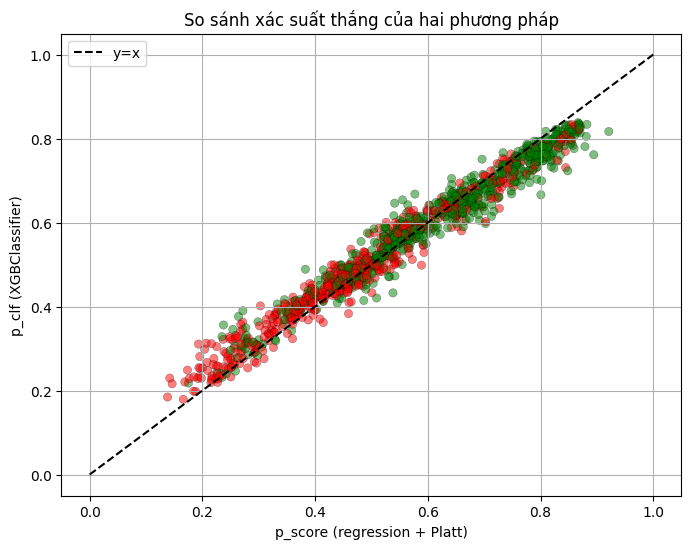

In [40]:
# ============================================================
# SO SÁNH p_score và p_clf (classifier)
# ============================================================
# Dùng best_clf đã được tuning, fit lại trên toàn bộ train
clf = best_clf
clf.fit(X_train, y_win_train)
p_clf = clf.predict_proba(X_test)[:, 1]

# Gán GAME_ID để merge
test_df_with_id = test_df.copy()
test_df_with_id['p_score'] = p_score
test_df_with_id['p_clf'] = p_clf
test_df_with_id['true_win'] = y_win_test
test_df_with_id['pred_margin'] = pred_margin

# 1. Tương quan Pearson
corr, _ = pearsonr(p_score, p_clf)
print(f"Tương quan Pearson giữa p_score và p_clf: {corr:.4f}")

# 2. Tỉ lệ bất đồng
disagree = ((p_score >= 0.5) != (p_clf >= 0.5)).sum()
disagree_rate = disagree / len(p_score)
print(f"Disagreement rate (khác dự đoán thắng/thua): {disagree_rate:.2%}")

# 3. Kiểm tra các trận bất đồng có margin nhỏ không?
mask_disagree = ((p_score >= 0.5) != (p_clf >= 0.5))
abs_margin_disagree = np.abs(test_df_with_id.loc[mask_disagree, 'pred_margin'])
abs_margin_all = np.abs(pred_margin)
print(f"|pred_margin| trung bình (các trận bất đồng): {abs_margin_disagree.mean():.2f}")
print(f"|pred_margin| trung bình (tất cả): {abs_margin_all.mean():.2f}")

# Vẽ scatter plot
plt.figure(figsize=(8, 6))
colors = test_df_with_id['true_win'].map({0: 'red', 1: 'green'})
plt.scatter(p_score, p_clf, c=colors, alpha=0.5, edgecolors='k', linewidth=0.3)
plt.plot([0,1], [0,1], 'k--', label='y=x')
plt.xlabel('p_score (regression + Platt)')
plt.ylabel('p_clf (XGBClassifier)')
plt.title('So sánh xác suất thắng của hai phương pháp')
plt.legend()
plt.grid(True)
plt.show()

# STACKING ENSEMBLE


In [41]:
# ============================================================
# STACKING (XGB+Platt) – KHÔNG LIGHTGBM, TRAIN LẠI OOF
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

# Tạo OOF predictions cho 2 base models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs_2cols = np.zeros((len(X_train), 2))  # cột 0: p_score_fold, cột 1: p_clf_fold

print("Đang tạo OOF predictions...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_win_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_win_train.iloc[train_idx], y_win_train.iloc[val_idx]
    y_margin_tr = y_margin_train.iloc[train_idx]

    # 1. Train XGBRegressor trên fold train -> predict margin trên val
    reg_fold = XGBRegressor(**best_reg.get_params())
    reg_fold.fit(X_tr, y_margin_tr)
    oof_margin = reg_fold.predict(X_val)

    # Platt calibration trên fold train
    calib_fold = LogisticRegression(C=1e6, solver='lbfgs', random_state=42)
    calib_fold.fit(oof_margin.reshape(-1, 1), y_val)
    p_score_fold = calib_fold.predict_proba(oof_margin.reshape(-1, 1))[:, 1]

    # 2. Train XGBClassifier trên fold train
    clf_fold = XGBClassifier(**best_clf.get_params())
    clf_fold.fit(X_tr, y_tr)
    p_clf_fold = clf_fold.predict_proba(X_val)[:, 1]

    oof_probs_2cols[val_idx, 0] = p_score_fold
    oof_probs_2cols[val_idx, 1] = p_clf_fold
    print(f"  Fold {fold+1}: done")

# Huấn luyện meta model
meta_model = LogisticRegression(C=1.0, solver='lbfgs', random_state=42)
meta_model.fit(oof_probs_2cols, y_win_train)

# Dự đoán trên test (đã có p_score, p_clf từ các cell trước)
test_probs_2cols = np.column_stack([p_score, p_clf])
p_stacked = meta_model.predict_proba(test_probs_2cols)[:, 1]

# Đánh giá
acc_stacked = accuracy_score(y_win_test, p_stacked >= 0.5)
auc_stacked = roc_auc_score(y_win_test, p_stacked)
print(f"\nStacking (XGB+Platt only) accuracy: {acc_stacked:.4f}, AUC: {auc_stacked:.4f}")

Đang tạo OOF predictions...
  Fold 1: done
  Fold 2: done
  Fold 3: done
  Fold 4: done
  Fold 5: done

Stacking (XGB+Platt only) accuracy: 0.6890, AUC: 0.7306


# ENSEMBLE


KẾT QUẢ CÁC PHƯƠNG PHÁP TRÊN TEST SET (2025-26)
Method                              Accuracy     AUC          F1          
------------------------------------------------------------
Score only (Platt)                  0.6907       0.7292       0.7362      
Classifier (XGB)                    0.6824       0.7304       0.7296      
Stacking (XGB+Platt only)           0.6890       0.7306       0.7345      


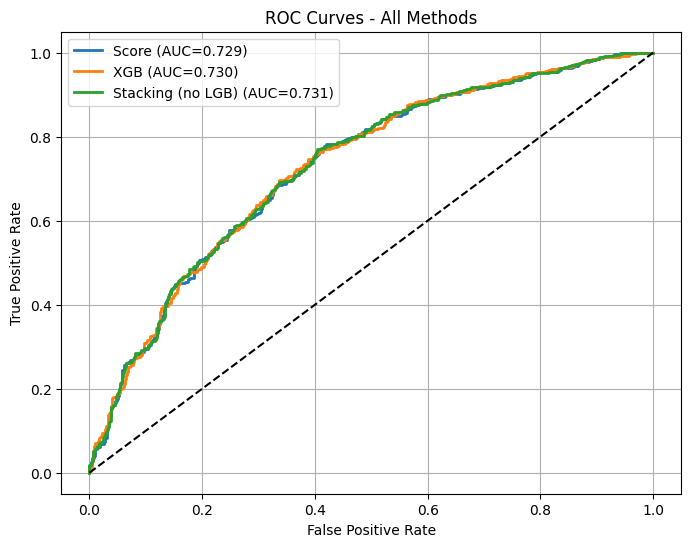

In [42]:
# ============================================================
# ENSEMBLE CUỐI CÙNG (so sánh các phương pháp chính) – VỚI STACKING KHÔNG LGB
# ============================================================
from sklearn.metrics import f1_score

print("="*60)
print("KẾT QUẢ CÁC PHƯƠNG PHÁP TRÊN TEST SET (2025-26)")
print("="*60)
print(f"{'Method':<35} {'Accuracy':<12} {'AUC':<12} {'F1':<12}")
print("-"*60)

# Score only (Platt)
acc_score_val = acc_score
auc_score_val = roc_auc_score(y_win_test, p_score)
f1_score_val = f1_score(y_win_test, p_score >= 0.5)
print(f"{'Score only (Platt)':<35} {acc_score_val:<12.4f} {auc_score_val:<12.4f} {f1_score_val:<12.4f}")

# Classifier (XGB)
acc_clf = accuracy_score(y_win_test, p_clf >= 0.5)
auc_clf = roc_auc_score(y_win_test, p_clf)
f1_clf = f1_score(y_win_test, p_clf >= 0.5)
print(f"{'Classifier (XGB)':<35} {acc_clf:<12.4f} {auc_clf:<12.4f} {f1_clf:<12.4f}")

# Stacking (XGB+Platt only) – đã tính ở cell trước (p_stacked, acc_stacked, auc_stacked)
f1_stacked = f1_score(y_win_test, p_stacked >= 0.5)
print(f"{'Stacking (XGB+Platt only)':<35} {acc_stacked:<12.4f} {auc_stacked:<12.4f} {f1_stacked:<12.4f}")

# Biểu đồ ROC so sánh
from sklearn.metrics import roc_curve
plt.figure(figsize=(8,6))
for name, prob in [('Score', p_score), ('XGB', p_clf), ('Stacking (no LGB)', p_stacked)]:
    fpr, tpr, _ = roc_curve(y_win_test, prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc_score(y_win_test, prob):.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Methods')
plt.legend()
plt.grid(True)
plt.show()

#KIỂM TRA LOGIC

## TRƯỚC STACKING (REGRESSION VS CLASSIFICATION)

PHÂN TÍCH DISAGREEMENT GIỮA CLASSIFIER VÀ REGRESSION
Tổng số trận test: 1209
Số trận disagreement: 56 (4.63%)
Số trận agreement: 1153 (95.37%)

--- |pred_margin| thống kê ---
Agreement:   mean=4.84, median=4.36
Disagreement: mean=0.56, median=0.42

--- Kết quả thực tế của các trận disagreement ---
Trong đó đội nhà thực sự thắng: 24/56 (42.9%)
Đội nhà thực sự thua: 32/56 (57.1%)

--- Hướng disagreement ---
Classifier bảo Home Win, Regression bảo Away Win: 29 trận
Classifier bảo Away Win, Regression bảo Home Win: 27 trận


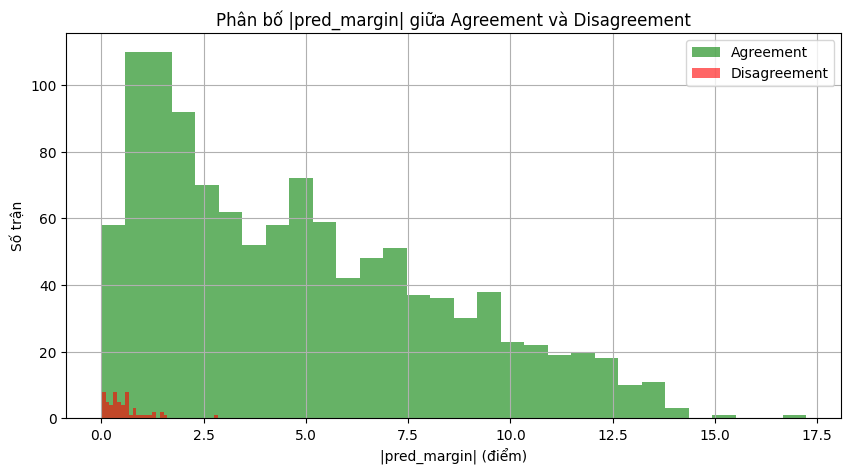


--- 10 trận disagreement đầu tiên (GAME_ID, pred_margin, p_clf, p_score, true_win) ---
 GAME_ID  pred_margin    p_clf  p_score  true_win
22500594    -0.188915 0.507894 0.479186         0
22500805     0.174372 0.516400 0.492426         0
22500111     0.052451 0.527537 0.487981         1
22500133     1.264884 0.470863 0.532161         1
22500473    -0.618567 0.536790 0.463566         0
22500677     0.061018 0.529566 0.488293         0
22500861    -0.079985 0.500661 0.483154         0
22501044    -0.039970 0.514599 0.484612         0
22500591     0.635560 0.420425 0.509248         1
22501226    -0.371625 0.521869 0.472537         0

Số trận disagreement có |pred_margin| < 3: 56/56 (100.0%)


In [43]:
# ============================================================
# PHÂN TÍCH DISAGREEMENT GIỮA CLASSIFIER VÀ REGRESSION (ĐÃ SỬA LỖI)
# ============================================================

# Dự đoán nhị phân từ mỗi mô hình
pred_clf_binary = (p_clf >= 0.5).astype(int)
pred_score_binary = (p_score >= 0.5).astype(int)

# Các trận disagreement
disagree_mask = (pred_clf_binary != pred_score_binary)
n_disagree = disagree_mask.sum()
n_total = len(p_clf)
disagree_rate = n_disagree / n_total

print("="*60)
print("PHÂN TÍCH DISAGREEMENT GIỮA CLASSIFIER VÀ REGRESSION")
print("="*60)
print(f"Tổng số trận test: {n_total}")
print(f"Số trận disagreement: {n_disagree} ({disagree_rate:.2%})")
print(f"Số trận agreement: {n_total - n_disagree} ({1-disagree_rate:.2%})")

# Phân bố của |pred_margin| trong các trận agreement vs disagreement
abs_margin = np.abs(pred_margin)
abs_margin_agree = abs_margin[~disagree_mask]
abs_margin_disagree = abs_margin[disagree_mask]

print("\n--- |pred_margin| thống kê ---")
print(f"Agreement:   mean={abs_margin_agree.mean():.2f}, median={np.median(abs_margin_agree):.2f}")
print(f"Disagreement: mean={abs_margin_disagree.mean():.2f}, median={np.median(abs_margin_disagree):.2f}")

# True label trong các trận disagreement
true_win_disagree = y_win_test[disagree_mask]
home_win_disagree = true_win_disagree.sum()
home_loss_disagree = len(true_win_disagree) - home_win_disagree
print("\n--- Kết quả thực tế của các trận disagreement ---")
print(f"Trong đó đội nhà thực sự thắng: {home_win_disagree}/{n_disagree} ({home_win_disagree/n_disagree:.1%})")
print(f"Đội nhà thực sự thua: {home_loss_disagree}/{n_disagree} ({home_loss_disagree/n_disagree:.1%})")

# Xem xét hướng disagreement
type1 = (pred_clf_binary == 1) & (pred_score_binary == 0)   # classifier home win, regression away win
type2 = (pred_clf_binary == 0) & (pred_score_binary == 1)   # classifier away win, regression home win
print(f"\n--- Hướng disagreement ---")
print(f"Classifier bảo Home Win, Regression bảo Away Win: {type1.sum()} trận")
print(f"Classifier bảo Away Win, Regression bảo Home Win: {type2.sum()} trận")

# Vẽ biểu đồ phân bố |pred_margin| theo agreement/disagreement
plt.figure(figsize=(10,5))
plt.hist(abs_margin_agree, bins=30, alpha=0.6, label='Agreement', color='green')
plt.hist(abs_margin_disagree, bins=30, alpha=0.6, label='Disagreement', color='red')
plt.xlabel('|pred_margin| (điểm)')
plt.ylabel('Số trận')
plt.title('Phân bố |pred_margin| giữa Agreement và Disagreement')
plt.legend()
plt.grid(True)
plt.show()

# Nếu muốn xem chi tiết một số trận disagreement (có GAME_ID)
if 'GAME_ID' in test_df.columns:
    disagree_df = test_df[disagree_mask].copy()
    disagree_df['pred_margin'] = pred_margin[disagree_mask]
    disagree_df['p_clf'] = p_clf[disagree_mask]
    disagree_df['p_score'] = p_score[disagree_mask]
    disagree_df['true_win'] = y_win_test[disagree_mask]
    print("\n--- 10 trận disagreement đầu tiên (GAME_ID, pred_margin, p_clf, p_score, true_win) ---")
    print(disagree_df[['GAME_ID', 'pred_margin', 'p_clf', 'p_score', 'true_win']].head(10).to_string(index=False))
else:
    print("\n(Không có cột GAME_ID trong test_df để hiển thị chi tiết)")

# Kiểm tra xem disagreement có xảy ra chủ yếu khi |pred_margin| nhỏ không
threshold_small = 3
small_margin_disagree = (abs_margin_disagree < threshold_small).sum()
print(f"\nSố trận disagreement có |pred_margin| < {threshold_small}: {small_margin_disagree}/{n_disagree} ({small_margin_disagree/n_disagree:.1%})")

## STACKING



PHÂN TÍCH DISAGREEMENT GIỮA STACKING VÀ BASE MODELS
Disagreement giữa Stacking và Score: 12 trận (0.99%)
Disagreement giữa Stacking và Classifier: 44 trận (3.64%)

Trong 56 trận disagreement giữa Score và Classifier:
  - Stacking dự đoán ĐÚNG: 31 trận (55.4%)
  - Stacking dự đoán SAI:  25 trận (44.6%)

  |pred_margin| trung bình khi Stacking ĐÚNG: 0.48
  |pred_margin| trung bình khi Stacking SAI:  0.65


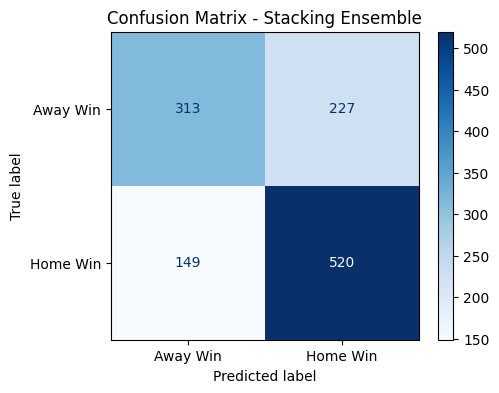

In [44]:
print("\n" + "="*60)
print("PHÂN TÍCH DISAGREEMENT GIỮA STACKING VÀ BASE MODELS")
print("="*60)

# So sánh Stacking vs Score (regression + calibration)
pred_stacked_binary = (p_stacked >= 0.5).astype(int)
disagree_stack_score = (pred_stacked_binary != pred_score_binary)
n_disagree_stack_score = disagree_stack_score.sum()
print(f"Disagreement giữa Stacking và Score: {n_disagree_stack_score} trận ({n_disagree_stack_score/n_total:.2%})")

# So sánh Stacking vs Classifier
disagree_stack_clf = (pred_stacked_binary != pred_clf_binary)
n_disagree_stack_clf = disagree_stack_clf.sum()
print(f"Disagreement giữa Stacking và Classifier: {n_disagree_stack_clf} trận ({n_disagree_stack_clf/n_total:.2%})")

# Kiểm tra những trận mà Score và Classifier disagree, nhưng Stacking chọn đúng/ sai
if n_disagree > 0:
    # Trường hợp Score và Classifier bất đồng
    mask_disagree = (pred_clf_binary != pred_score_binary)
    # Trong đó Stacking dự đoán đúng
    stacking_correct_on_disagree = (pred_stacked_binary == y_win_test) & mask_disagree
    stacking_wrong_on_disagree = (pred_stacked_binary != y_win_test) & mask_disagree
    print(f"\nTrong {n_disagree} trận disagreement giữa Score và Classifier:")
    print(f"  - Stacking dự đoán ĐÚNG: {stacking_correct_on_disagree.sum()} trận ({stacking_correct_on_disagree.sum()/n_disagree:.1%})")
    print(f"  - Stacking dự đoán SAI:  {stacking_wrong_on_disagree.sum()} trận ({stacking_wrong_on_disagree.sum()/n_disagree:.1%})")

    # Phân bố |pred_margin| của các trận disagreement mà Stacking đúng/sai
    abs_margin_stack_correct = abs_margin[mask_disagree & stacking_correct_on_disagree]
    abs_margin_stack_wrong = abs_margin[mask_disagree & stacking_wrong_on_disagree]
    if len(abs_margin_stack_correct) > 0:
        print(f"\n  |pred_margin| trung bình khi Stacking ĐÚNG: {abs_margin_stack_correct.mean():.2f}")
    if len(abs_margin_stack_wrong) > 0:
        print(f"  |pred_margin| trung bình khi Stacking SAI:  {abs_margin_stack_wrong.mean():.2f}")

# Vẽ confusion matrix của Stacking
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_win_test, pred_stacked_binary,
                                        display_labels=['Away Win', 'Home Win'],
                                        cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix - Stacking Ensemble')
plt.show()

# Lưu mô hình


In [45]:
import joblib

# Các mô hình cho stacking ensemble (không LightGBM)
joblib.dump(best_reg, 'margin_model.pkl')           # XGBRegressor cho margin
joblib.dump(reg_total, 'total_points_model.pkl')    # XGBRegressor cho tổng điểm
joblib.dump(best_clf, 'xgb_clf.pkl')                # XGBClassifier
joblib.dump(calibrator, 'calibrator.pkl')           # Platt calibration (LogisticRegression)
joblib.dump(meta_model, 'meta_model_1.pkl')       # Meta model (LogisticRegression) cho stacking 2 models

print("✅ Đã lưu tất cả mô hình cho stacking ensemble (không LightGBM).")

✅ Đã lưu tất cả mô hình cho stacking ensemble (không LightGBM).
